In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time
import random

In [12]:
n_harmonics = 10
w_max = 900
f_s = 2000
N = 256
t_max = N / f_s

In [13]:
def generate_random_signal(n_harmonics, w_max, time_array):
    signal = np.zeros_like(time_array)
    dw = w_max / n_harmonics

    amplitudes = []
    phases = []
    frequencies = []

    for j in range(1, n_harmonics + 1):
        w_j = j * dw
        A_j = random.uniform(0, 1)
        phi_j = random.uniform(0, 2 * np.pi)

        signal += A_j * np.sin(w_j * time_array + phi_j)

        amplitudes.append(A_j)
        phases.append(phi_j)
        frequencies.append(w_j)

    return signal, amplitudes, phases, frequencies

def dft_custom(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-2j * np.pi * k * n / N)
    return X

def fft_custom(x):
    N = len(x)
    if N <= 1:
        return x

    even = fft_custom(x[0::2])
    odd = fft_custom(x[1::2])

    T = [np.exp(-2j * np.pi * k / N) * odd[k] for k in range(N // 2)]

    return np.array([even[k] + T[k] for k in range(N // 2)] + \
                    [even[k] - T[k] for k in range(N // 2)])

In [14]:
t = np.linspace(0, t_max, N)
x_signal, A_x, phi_x, w_x = generate_random_signal(n_harmonics, w_max, t)

print(f"Кількість відліків N: {N}")

# Запуск ДПФ
start_time = time.perf_counter()
X_dft = dft_custom(x_signal)
dft_time = time.perf_counter() - start_time
print(f"Час виконання ДПФ: {dft_time:.6f} сек")

# Запуск ШПФ
start_time = time.perf_counter()
X_fft = fft_custom(x_signal)
fft_time = time.perf_counter() - start_time
print(f"Час виконання ШПФ: {fft_time:.6f} сек")

# Перевірка бібліотечним методом
start_time = time.perf_counter()
X_numpy = np.fft.fft(x_signal)
numpy_time = time.perf_counter() - start_time
print(f"Час виконання numpy.fft: {numpy_time:.6f} сек")

magnitude_dft = np.abs(X_dft) / (N / 2)
magnitude_fft = np.abs(X_fft) / (N / 2)

freqs = np.fft.fftfreq(N, t_max/N)

Кількість відліків N: 256
Час виконання ДПФ: 0.066603 сек
Час виконання ШПФ: 0.001767 сек
Час виконання numpy.fft: 0.000093 сек


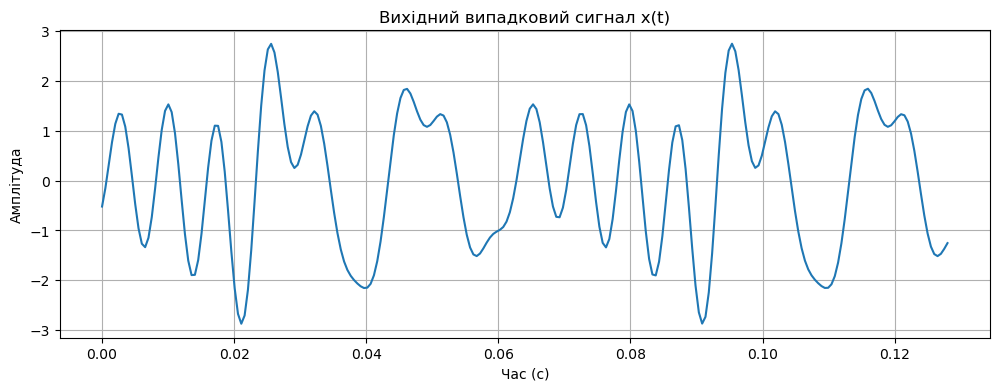

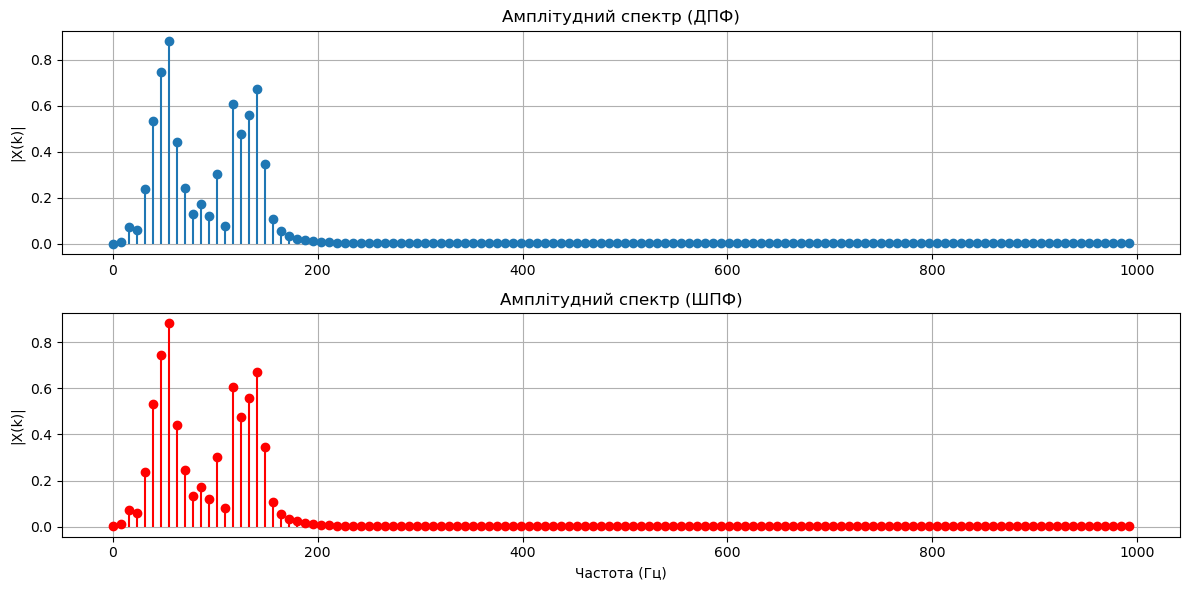

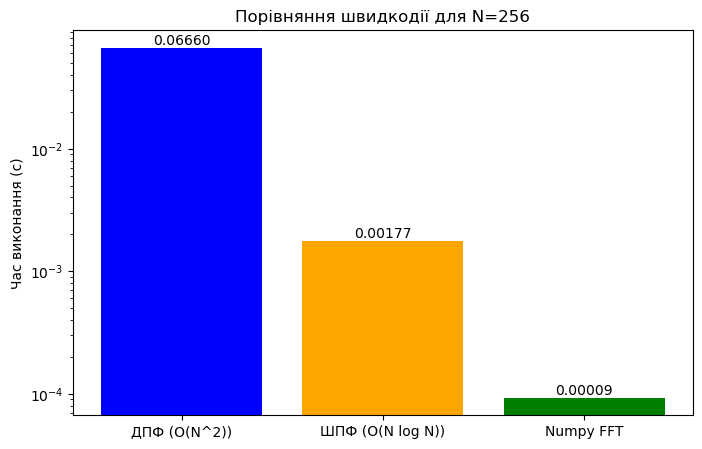

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(t, x_signal)
plt.title("Вихідний випадковий сигнал x(t)")
plt.xlabel("Час (с)")
plt.ylabel("Амплітуда")
plt.grid(True)
plt.show()

half_N = N // 2
plt.figure(figsize=(12, 6))

# ДПФ Спектр
plt.subplot(2, 1, 1)
plt.stem(freqs[:half_N], magnitude_dft[:half_N], basefmt=" ")
plt.title("Амплітудний спектр (ДПФ)")
plt.ylabel("|X(k)|")
plt.grid(True)

# ШПФ Спектр
plt.subplot(2, 1, 2)
plt.stem(freqs[:half_N], magnitude_fft[:half_N], basefmt=" ", linefmt='r-', markerfmt='ro')
plt.title("Амплітудний спектр (ШПФ)")
plt.xlabel("Частота (Гц)")
plt.ylabel("|X(k)|")
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
methods = ['ДПФ (O(N^2))', 'ШПФ (O(N log N))', 'Numpy FFT']
times = [dft_time, fft_time, numpy_time]
bars = plt.bar(methods, times, color=['blue', 'orange', 'green'])
plt.ylabel("Час виконання (с)")
plt.title(f"Порівняння швидкодії для N={N}")
plt.yscale('log')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.5f}', ha='center', va='bottom')
plt.show()